In [2]:
!pip install psycopg2-binary

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 11.9 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="sales_analysis",
    user="postgres",
    password=""
)

query = "SELECT * FROM analytics.sales"

df = pd.read_sql(query, conn)

df.head()

C:\Users\faust\AppData\Local\Temp\ipykernel_5888\2170376722.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,product_id,country,city,state,region,sales,quantity,discount,profit,sale_id
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,FUR-BO-10001798,United States,Henderson,Kentucky,South,261.96,2,0.00,41.91,1
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,FUR-CH-10000454,United States,Henderson,Kentucky,South,731.94,3,0.00,219.58,2
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,OFF-LA-10000240,United States,Los Angeles,California,West,14.62,2,0.00,6.87,3
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,FUR-TA-10000577,United States,Fort Lauderdale,Florida,South,957.58,5,0.45,-383.03,4
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,OFF-ST-10000760,United States,Fort Lauderdale,Florida,South,22.37,2,0.20,2.52,5


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,product_id,country,city,state,region,sales,quantity,discount,profit,sale_id
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,FUR-BO-10001798,United States,Henderson,Kentucky,South,261.96,2,0.00,41.91,1
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,FUR-CH-10000454,United States,Henderson,Kentucky,South,731.94,3,0.00,219.58,2
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,OFF-LA-10000240,United States,Los Angeles,California,West,14.62,2,0.00,6.87,3
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,FUR-TA-10000577,United States,Fort Lauderdale,Florida,South,957.58,5,0.45,-383.03,4
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,OFF-ST-10000760,United States,Fort Lauderdale,Florida,South,22.37,2,0.20,2.52,5


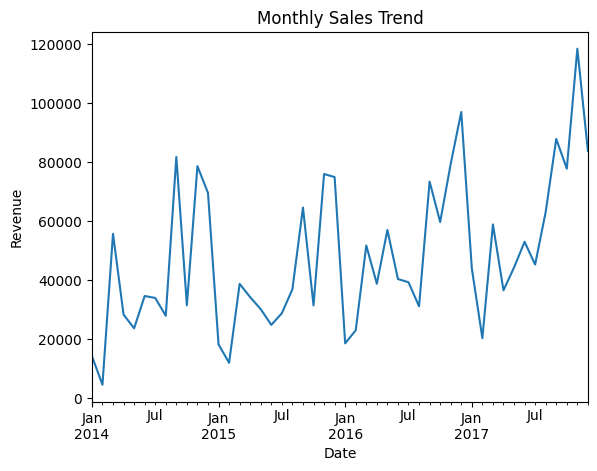

In [5]:
import matplotlib.pyplot as plt

monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))['sales']
    .sum()
)

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

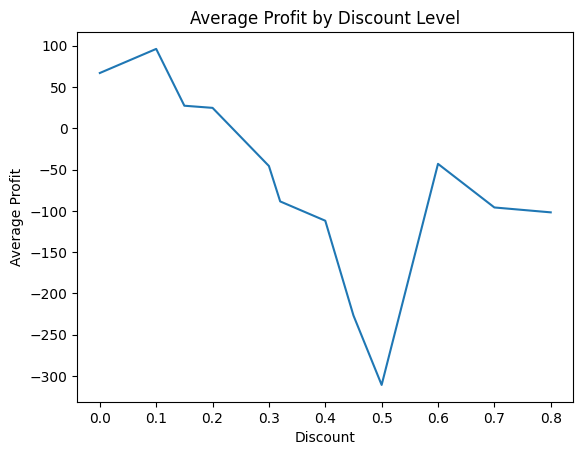

In [6]:
discount_profit = (
    df.groupby('discount')['profit']
    .mean()
)

discount_profit.plot()

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

In [7]:
df.groupby('discount').agg({
    'profit': 'mean',
    'sales': 'count'
})

,profit,sales
discount,,
0.00,66.900350,4798
0.10,96.055426,94
0.15,27.288077,52
0.20,24.702806,3657
0.30,-45.679912,227
0.32,-88.561481,27
0.40,-111.927573,206
0.45,-226.647273,11
0.50,-310.704697,66


In [8]:
df[df['discount'] == 0.6]

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,product_id,country,city,state,region,sales,quantity,discount,profit,sale_id
36,CA-2016-117590,2016-12-08,2016-12-10,First Class,GH-14485,Gene Hale,Corporate,FUR-FU-10003664,United States,Richardson,Texas,Central,190.92,5,0.6,-147.96,37
76,US-2017-118038,2017-12-09,2017-12-11,First Class,KB-16600,Ken Brennan,Corporate,FUR-FU-10000260,United States,Houston,Texas,Central,9.71,3,0.6,-5.82,77
78,US-2014-147606,2014-11-26,2014-12-01,Second Class,JE-15745,Joel Eaton,Consumer,FUR-FU-10003194,United States,Houston,Texas,Central,19.30,5,0.6,-14.48,79
238,CA-2016-157749,2016-06-04,2016-06-09,Second Class,KL-16645,Ken Lonsdale,Consumer,FUR-FU-10000576,United States,Chicago,Illinois,Central,419.68,5,0.6,-356.73,239
239,CA-2016-157749,2016-06-04,2016-06-09,Second Class,KL-16645,Ken Lonsdale,Consumer,FUR-FU-10004351,United States,Chicago,Illinois,Central,11.69,3,0.6,-4.68,240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,FUR-FU-10004666,United States,San Antonio,Texas,Central,17.50,3,0.6,-10.06,9776
9831,CA-2014-113257,2014-12-16,2014-12-18,Second Class,SC-20305,Sean Christensen,Consumer,FUR-FU-10001706,United States,Beaumont,Texas,Central,8.62,7,0.6,-2.59,9832
9834,CA-2016-126627,2016-10-10,2016-10-12,First Class,WB-21850,William Brown,Consumer,FUR-FU-10004963,United States,La Porte,Texas,Central,14.00,4,0.6,-6.30,9835
9844,CA-2014-163867,2014-06-03,2014-06-06,First Class,RE-19450,Richard Eichhorn,Consumer,FUR-FU-10001475,United States,Decatur,Illinois,Central,61.54,7,0.6,-40.00,9845


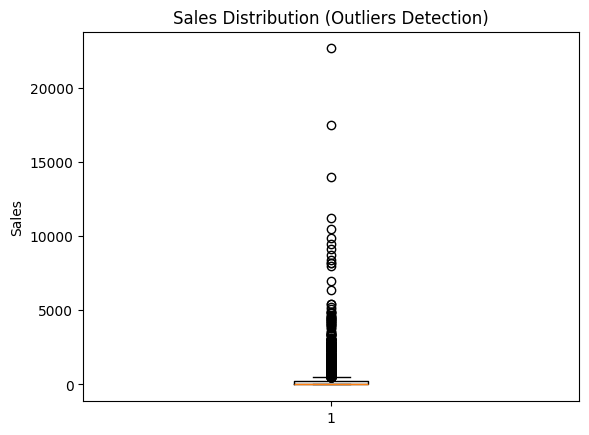

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['sales'])

plt.title("Sales Distribution (Outliers Detection)")
plt.ylabel("Sales")
plt.show()

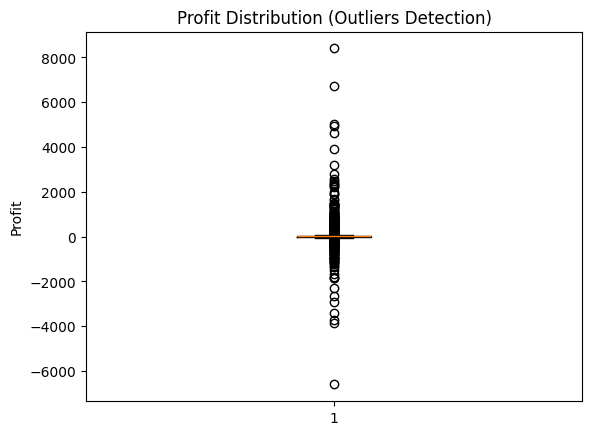

In [10]:
plt.figure()
plt.boxplot(df['profit'])

plt.title("Profit Distribution (Outliers Detection)")
plt.ylabel("Profit")
plt.show()

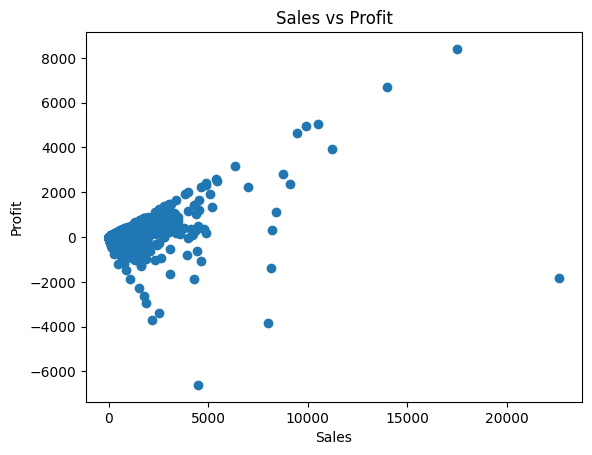

In [11]:
plt.figure()
plt.scatter(df['sales'], df['profit'])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

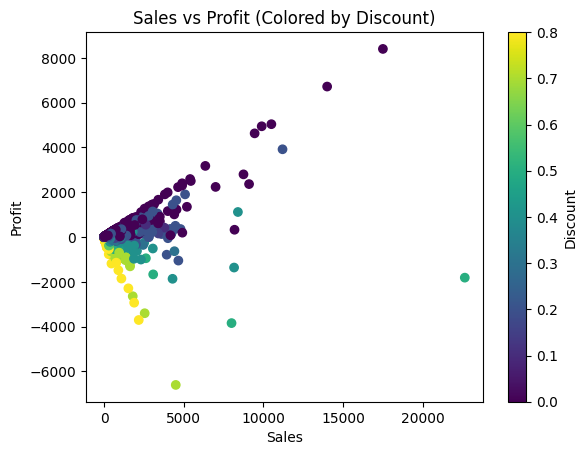

In [12]:
plt.figure()
plt.scatter(df['sales'], df['profit'], c=df['discount'])

plt.title("Sales vs Profit (Colored by Discount)")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.colorbar(label="Discount")
plt.show()


## PYTHON ANALYSIS SUMMARY

Key Findings:
 - Sales show clear seasonal trends with peaks in March, September, November and December.
 - Higher discount levels are strongly associated with lower profitability.
 - Extreme negative profit transactions are linked to high discount values.
 - Outliers reveal high-revenue transactions that generate losses.

Conclusion:

 Python analysis validated SQL findings and provided
 visual confirmation of key business insights.
